In [10]:
import pandas as pd
import numpy as np

from LIF_SNN_test_new import SNNLayer

**Parameters**

In [19]:
# Input/Output size
n_inputs = 16
n_outputs = 3

# Training params
n_epochs = 50

# Neuron hyperparameters
beta = 0.90
threshold = 3.0
reset = 0.0

neuron_params = {"beta":beta, "threshold":threshold, "reset":reset}

# Synapse parameters
learning_rate = 0.1
initial_weight = None
tau_pre = 5
tau_post = 5
tau_e = 10
A_plus = 0.1
A_minus = 0.1
min_weight = 0.05
max_weight = 1.0

synapse_params = {"learning_rate":learning_rate, "w_init":initial_weight, "tau_pre":tau_pre, "tau_post":tau_post, "tau_e":tau_e, "A_plus":A_plus, "A_minus":A_minus, "w_min":min_weight, "w_max":max_weight}

**Initialize network**

In [20]:
SNN = SNNLayer(n_inputs=n_inputs, n_outputs=n_outputs, synapse_params=synapse_params, neuron_params=neuron_params)

**Test data**

In [21]:
spiketrains = pd.read_csv("Frame_test_spiketrains.csv")

test_dist_train = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 
                   0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
                   0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

test_obj_req = [
    [0, 0, 0],  # 0
    [0, 0, 0],  # 1
    [0, 0, 0],  # 2
    [0, 0, 0],  # 3
    [0, 0, 0],  # 4
    [0, 0, 0],  # 5
    [0, 0, 0],  # 6
    [0, 0, 0],  # 7
    [0, 0, 0],  # 8
    [0, 0, 0],  # 9
    [0, 0, 0],  # 10
    [0, 0, 0],  # 11
    [0, 0, 0],  # 12
    [0, 0, 0],  # 13
    [0, 0, 0],  # 14
    [1, 0, 0],  # 15 - Object detected LEFT
    [1, 0, 0],  # 16
    [1, 0, 0],  # 17
    [1, 0, 0],  # 18
    [1, 0, 0],  # 19
    [1, 0, 0],  # 20
    [1, 0, 0],  # 21
    [1, 0, 0],  # 22
    [1, 0, 0],  # 23
    [1, 0, 0],  # 24
    [0, 1, 0],  # 25 - Object detected CENTRE
    [0, 1, 0],  # 26
    [0, 1, 0],  # 27
    [0, 1, 0],  # 28
    [0, 1, 0],  # 29
    [0, 1, 0],  # 30
    [0, 1, 0],  # 31
    [0, 0, 1],  # 32 - Object detected RIGHT
    [0, 0, 1],  # 33
    [0, 0, 1],  # 34
    [0, 0, 1],  # 35
    [0, 0, 1],  # 36 
    [0, 0, 1],  # 37
    [0, 0, 1],  # 38
    [0, 0, 1],  # 39
    [0, 1, 1],  # 40 - Object detected CENTRE again
    [0, 1, 0],  # 41
    [0, 1, 0],  # 42
    [0, 1, 0],  # 43
    [0, 1, 0],  # 44
    [0, 1, 0],  # 45
    [0, 1, 0],  # 46
    [0, 1, 0],  # 47
    [0, 1, 0],  # 48
    [0, 1, 0],  # 49
]

correct_outputs = []
for i in range(len(test_obj_req)):
    obj_l, obj_c, obj_r = test_obj_req[i]
    
    if obj_r:
        correct_outputs.append(2)      # object right → turn right
    elif obj_l:
        correct_outputs.append(1)      # object left → turn left
    elif obj_c or test_dist_train[i]:
        correct_outputs.append(1)      # object center or close → forward
    else:
        correct_outputs.append(1)      # nothing → forward/explore

input_spikes = []
for i in range(len(spiketrains)):
    row = spiketrains.iloc[i].tolist() + [test_dist_train[i]] + test_obj_req[i]
    input_spikes.append(row)

**Logging network activity**

In [22]:
# Initialize history lists
mem_hist = []
spike_hist = []
target_hist = []
weight_hist = []

n_correct = 0

**Run network**

In [23]:
# Repeat test for n epochs
for n in range(n_epochs):
    SNN.reset_state()
    # Iterate through spikes in each timestep
    for current_spikes, correct_output in zip(input_spikes, correct_outputs):

        # Forward pass with current timestep
        output_spikes = SNN.forward(input_spikes=current_spikes)

        # Find the "winning" neuron of current timestep
        winner_idx = SNN.winner_takes_all(output_spikes=output_spikes)

        # Check correct
        if winner_idx == correct_output:
            dopamine = 1.0

            ### Debug ###
            n_correct += 1
        else:
            dopamine = -1.0

        # Apply reward
        SNN.apply_reward(dopamine=dopamine, winner_idx=winner_idx)

        
        # Log results
        mem_hist.append([n.mem for n in SNN.neurons])
        spike_hist.append([n.spk for n in SNN.neurons])
        target_hist.append(correct_output)
        weight_hist.append(SNN.get_weights().copy())


    # Print results for each epoch
    print(f"--- Epoch ({n}) ---")
    print("Correct outputs:", n_correct)
    print()
    n_correct = 0


--- Epoch (0) ---
Correct outputs: 12

--- Epoch (1) ---
Correct outputs: 32

--- Epoch (2) ---
Correct outputs: 32

--- Epoch (3) ---
Correct outputs: 33

--- Epoch (4) ---
Correct outputs: 33

--- Epoch (5) ---
Correct outputs: 33

--- Epoch (6) ---
Correct outputs: 35

--- Epoch (7) ---
Correct outputs: 35

--- Epoch (8) ---
Correct outputs: 35

--- Epoch (9) ---
Correct outputs: 34

--- Epoch (10) ---
Correct outputs: 35

--- Epoch (11) ---
Correct outputs: 36

--- Epoch (12) ---
Correct outputs: 35

--- Epoch (13) ---
Correct outputs: 36

--- Epoch (14) ---
Correct outputs: 33

--- Epoch (15) ---
Correct outputs: 34

--- Epoch (16) ---
Correct outputs: 34

--- Epoch (17) ---
Correct outputs: 34

--- Epoch (18) ---
Correct outputs: 34

--- Epoch (19) ---
Correct outputs: 33

--- Epoch (20) ---
Correct outputs: 34

--- Epoch (21) ---
Correct outputs: 32

--- Epoch (22) ---
Correct outputs: 35

--- Epoch (23) ---
Correct outputs: 34

--- Epoch (24) ---
Correct outputs: 35

--- Epoch 

In [24]:
# Print final weights
import numpy as np
weights = SNN.get_weights()
print("Final weights (rows=output neurons, cols=inputs):")
print(np.round(weights, 3))

# Run one final pass to see per-sample decisions
print("\nPer-sample results:")
for i, (spikes, correct) in enumerate(zip(input_spikes, correct_outputs)):
    out = SNN.forward(input_spikes=spikes)
    winner = SNN.winner_takes_all(out)
    mems = [round(n.mem, 3) for n in SNN.neurons]
    print(f"  Sample {i}: winner={winner} correct={correct} {'✓' if winner==correct else '✗'} spikes={out} mems={mems}")

Final weights (rows=output neurons, cols=inputs):
[[0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05
  0.05  0.05  0.05  0.109]
 [0.637 0.217 0.089 0.597 0.618 0.329 0.602 0.764 0.123 0.92  0.857 0.942
  0.865 0.208 0.05  1.   ]
 [0.05  0.063 0.055 0.051 0.064 0.05  0.188 0.147 0.052 0.05  0.475 0.409
  0.05  0.05  0.085 0.072]]

Per-sample results:
  Sample 0: winner=0 correct=1 ✗ spikes=[0, 0, 0] mems=[np.float64(0.0), np.float64(0.0), np.float64(0.0)]
  Sample 1: winner=1 correct=1 ✓ spikes=[0, 0, 0] mems=[np.float64(0.2), np.float64(2.439), np.float64(0.873)]
  Sample 2: winner=1 correct=1 ✓ spikes=[0, 1, 0] mems=[np.float64(0.38), 0.0, np.float64(1.438)]
  Sample 3: winner=1 correct=1 ✓ spikes=[0, 0, 0] mems=[np.float64(0.492), np.float64(2.09), np.float64(1.869)]
  Sample 4: winner=1 correct=1 ✓ spikes=[0, 1, 0] mems=[np.float64(0.693), 0.0, np.float64(2.509)]
  Sample 5: winner=2 correct=1 ✗ spikes=[0, 0, 1] mems=[np.float64(0.824), np.float64(2.312), 0.0]


In [25]:
import matplotlib.pyplot as plt
import numpy as np


def plot_snn_summary(mem_hist, spike_hist, target_hist, weight_hist=None,
                     threshold=2.5, n_epochs=1, samples_per_epoch=50,
                     plot_last_n_epochs=3):
    """
    Single combined plot: accuracy, weight evolution, membrane dynamics.
    """
    time_steps = len(mem_hist)
    num_neurons = len(mem_hist[0])
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    neuron_labels = ['Neuron 0 (left)', 'Neuron 1 (forward)', 'Neuron 2 (right)']
    if num_neurons != 3:
        neuron_labels = [f'Neuron {i}' for i in range(num_neurons)]

    n_rows = 1 + num_neurons + num_neurons
    fig, axes = plt.subplots(n_rows, 1, figsize=(18, 3.2 * n_rows),
                              gridspec_kw={'hspace': 0.45})

    # ---- Accuracy ----
    ax = axes[0]
    if n_epochs > 1:
        epoch_acc = []
        for e in range(n_epochs):
            start = e * samples_per_epoch
            end = start + samples_per_epoch
            correct = 0
            for t in range(start, min(end, time_steps)):
                spks = spike_hist[t]
                spiking = [j for j, s in enumerate(spks) if s > 0]
                if len(spiking) == 1:
                    winner = spiking[0]
                elif len(spiking) > 1:
                    winner = spiking[0]
                else:
                    winner = int(np.argmax([mem_hist[t][j] for j in range(num_neurons)]))
                if winner == target_hist[t]:
                    correct += 1
            epoch_acc.append(correct / samples_per_epoch * 100)

        ax.plot(epoch_acc, marker='.', markersize=5, linewidth=1.2, color='#2ca02c')
        ax.axhline(y=100 / num_neurons, color='red', linestyle='--', alpha=0.5, label='Chance')
        ax.set_ylim(0, 105)
        ax.legend(fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("Training Accuracy per Epoch", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.tick_params(labelsize=10)

    # ---- Weight evolution ----
    if weight_hist is not None and len(weight_hist) > 0:
        n_inputs = weight_hist[0].shape[1]
        for j in range(num_neurons):
            ax = axes[1 + j]
            for i in range(n_inputs):
                w_over_time = [w[j, i] for w in weight_hist]
                ax.plot(w_over_time, linewidth=0.8, alpha=0.75)

            ax.set_title(f"{neuron_labels[j]} — Weights", fontsize=12, fontweight='bold')
            ax.set_ylabel("Weight", fontsize=11)
            ax.set_ylim(-0.02, 1.05)
            ax.grid(True, linestyle=':', alpha=0.4)
            ax.tick_params(labelsize=10)
        axes[num_neurons].set_xlabel("Timestep", fontsize=11)

    # ---- Membrane dynamics (last N epochs) ----
    last_start = max(0, (n_epochs - plot_last_n_epochs) * samples_per_epoch)
    mem_slice = mem_hist[last_start:]
    spike_slice = spike_hist[last_start:]
    target_slice = target_hist[last_start:]
    t_len = len(mem_slice)

    for j in range(num_neurons):
        ax = axes[1 + num_neurons + j]
        mems = [m[j] for m in mem_slice]
        spks = [s[j] for s in spike_slice]

        ax.plot(mems, color=colors[j % len(colors)], alpha=0.85, linewidth=1.0)
        ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.4, linewidth=0.8)

        # Spikes
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            ax.scatter(spike_times, [threshold] * len(spike_times),
                       color='red', marker='x', s=50, linewidths=1.5, zorder=5)

        # Target shading
        for t in range(t_len):
            if target_slice[t] == j:
                ax.axvspan(t, t + 1, color=colors[j % len(colors)], alpha=0.12)

        # Epoch boundaries
        for e in range(1, plot_last_n_epochs):
            boundary = e * samples_per_epoch
            if boundary < t_len:
                ax.axvline(x=boundary, color='gray', linestyle='-', alpha=0.4, linewidth=1)

        ax.set_title(f"{neuron_labels[j]} — Membrane (last {plot_last_n_epochs} epochs)",
                     fontsize=12, fontweight='bold')
        ax.set_ylabel("Membrane", fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.4)
        ax.tick_params(labelsize=10)

    axes[-1].set_xlabel("Timestep (relative)", fontsize=11)
    fig.suptitle("SNN Training Summary", fontsize=16, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.show()

C:\Users\eirik\AppData\Local\Temp\ipykernel_12832\1549364969.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


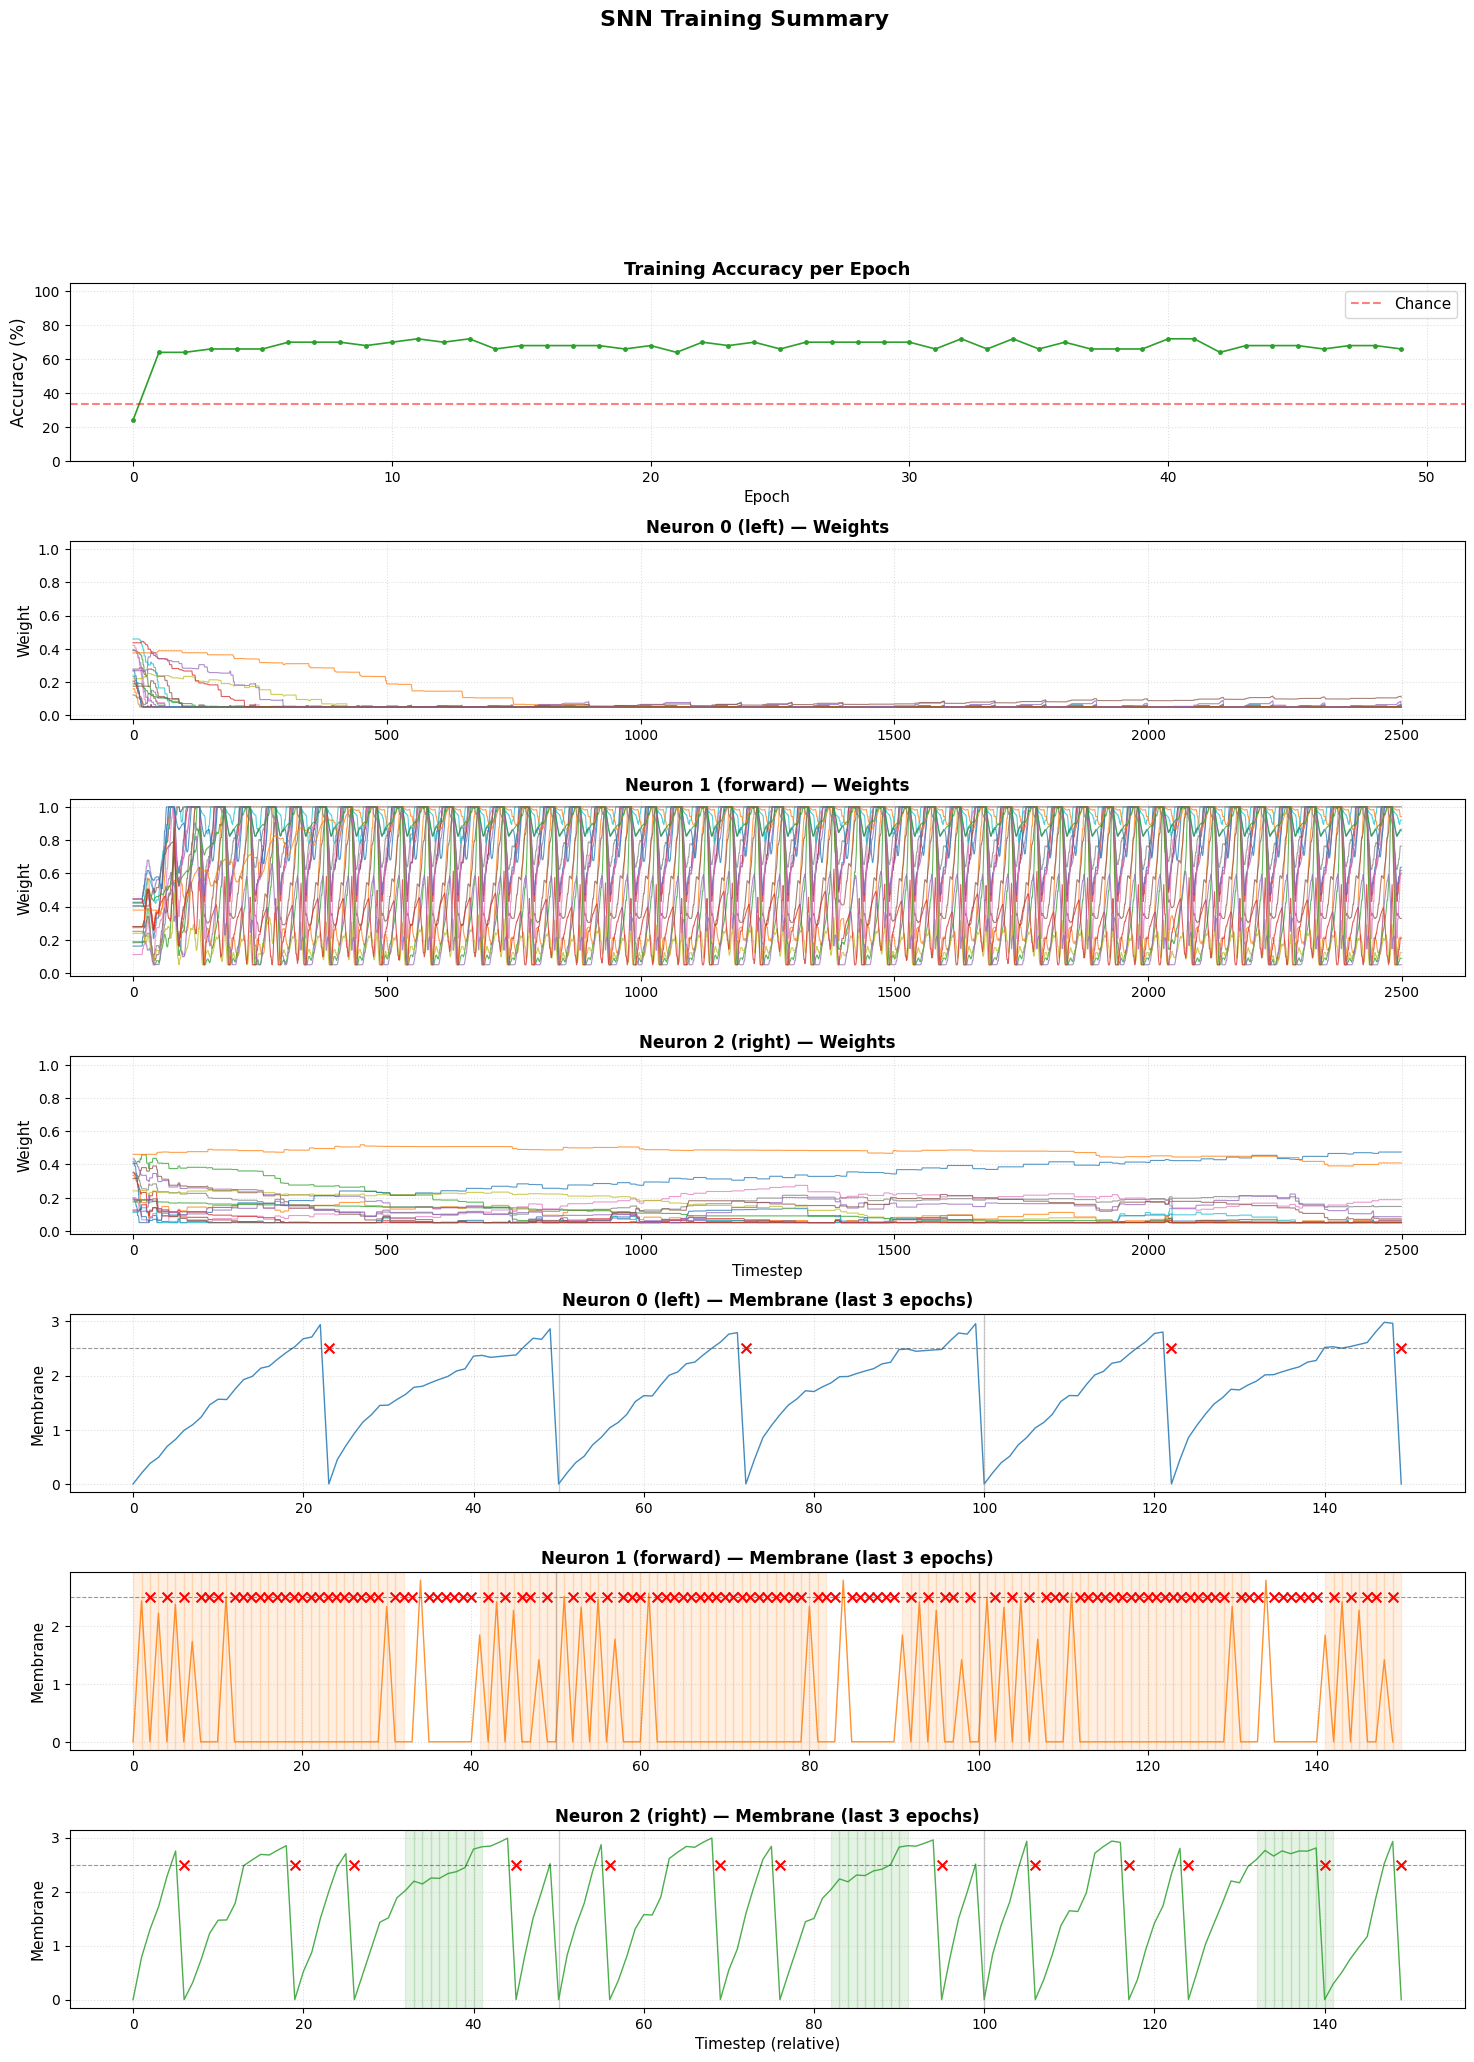

In [26]:
plot_snn_summary(mem_hist, spike_hist, target_hist, weight_hist,
                 threshold=2.5, n_epochs=n_epochs, 
                 samples_per_epoch=len(input_spikes),
                 plot_last_n_epochs=3)